# View PNML Models of Each Fragment

**Prerequisite:** Notebook `02_quality_measurments.ipynb` must have been run first.
That creates the PNML model files per fragment and per method.

This notebook loads the pre-exported PNML files, converts them to BPMN, and displays the diagram for each fragment's process model.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
from pathlib import Path
import re
sys.path.append('../')

from IPython.display import display, HTML

import pm4py
from pm4py.convert import convert_to_bpmn
from pm4py.visualization.bpmn import visualizer as bpmn_visualizer

## 1. Configuration

Point `PNML_DIR` to the folder containing the `.pnml` files exported by the evaluation pipeline.

In [2]:
# --- CONFIG ---
PNML_DIR = "../data/processed/BPIC/pnml"


## 2. Discover Methods and Fragments

PNML files are named as `{log}.{fragment_idx}.{method}.pnml` (e.g. `BPIC12.xes.gz.0.heuristic.pnml`).
Files matching `{log}.root.{method}.pnml` are root models.

We group them by method and fragment index automatically.

In [3]:
pnml_dir = Path(PNML_DIR)
if not pnml_dir.exists():
    print(f"Not found: {PNML_DIR}")
    print("Run evaluation() first to generate PNML files.")
else:
    all_files = sorted(pnml_dir.glob('*.pnml'))
    print(f"Found {len(all_files)} PNML files")
    for f in all_files:
        print(f"  {f.name}")

Found 6 PNML files
  BPIC12.xes.gz.0.heuristic.pnml
  BPIC12.xes.gz.1.heuristic.pnml
  BPIC12.xes.gz.2.heuristic.pnml
  BPIC12.xes.gz.3.heuristic.pnml
  BPIC12.xes.gz.4.heuristic.pnml
  BPIC12.xes.gz.root.heuristic.pnml


## 3. View BPMN for Each Fragment

Each fragment's PNML is converted to BPMN and displayed grouped by method.

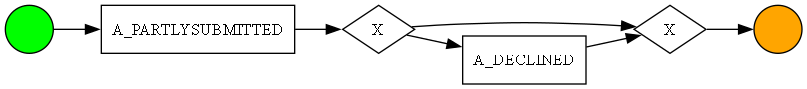

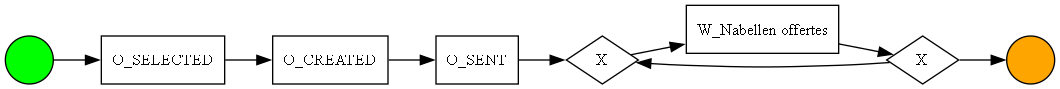

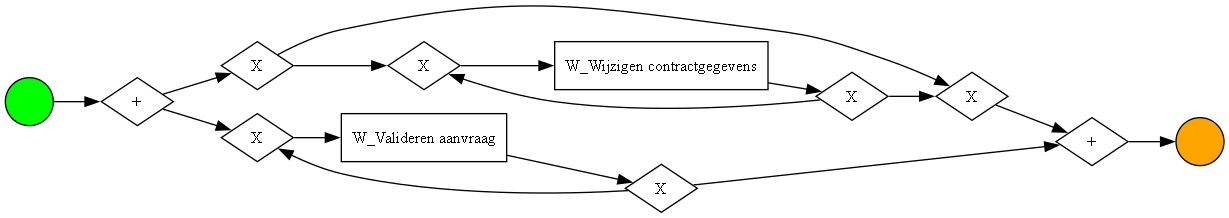

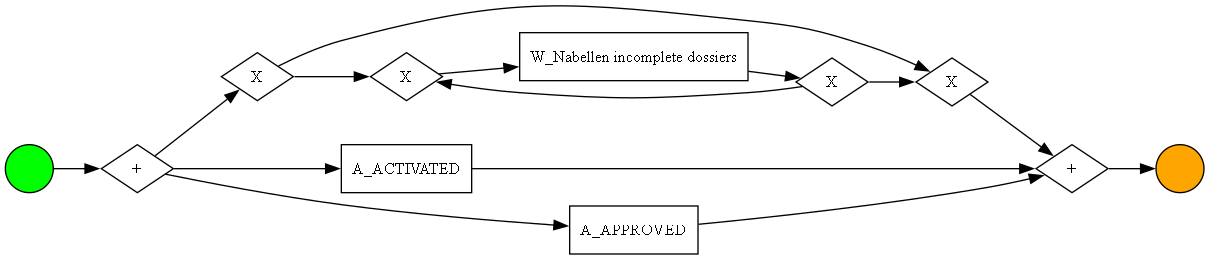

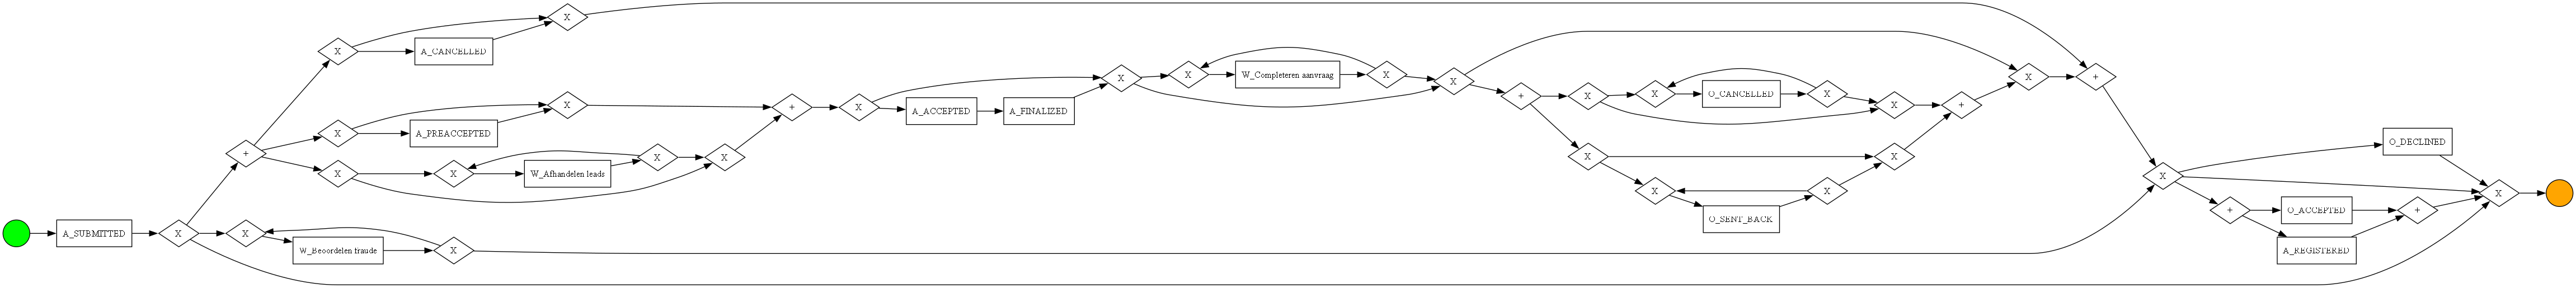

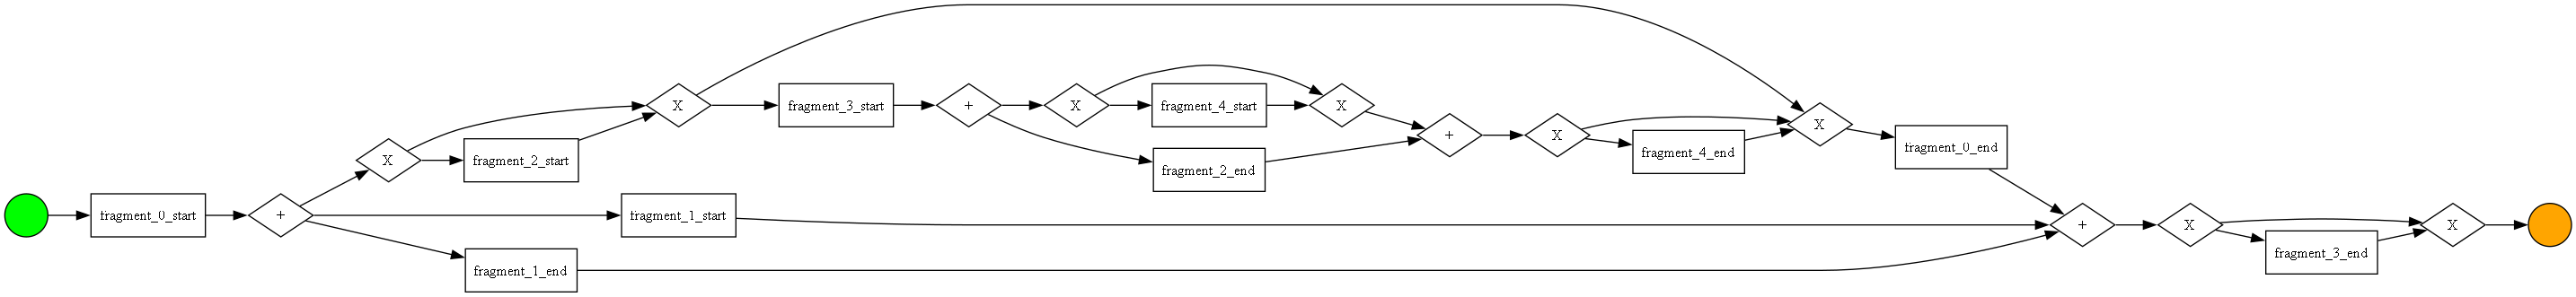

In [4]:
if pnml_dir.exists():
    # Pattern: {filename_base}.{idx}.{method}.pnml or {filename_base}.root.{method}.pnml
    pat = re.compile(r'^(.+?)\.(\d+)\.(.+)\.pnml$')
    root_pat = re.compile(r'^(.+?)\.root\.(.+)\.pnml$')

    fragments_by_method = {}  # {method: [(idx, fragment_path)]}
    root_by_method = {}       # {method: root_path}

    for f in pnml_dir.glob('*.pnml'):
        m = pat.match(f.name)
        if m:
            method = m.group(3)
            idx = int(m.group(2))
            fragments_by_method.setdefault(method, []).append((idx, f))
            continue
        m = root_pat.match(f.name)
        if m:
            method = m.group(2)
            root_by_method[method] = f

    for method in sorted(fragments_by_method):
        frags = sorted(fragments_by_method[method], key=lambda x: x[0])
        display(HTML(f'<hr><h2>Method: {method}</h2>'))

        for idx, fpath in frags:
            display(HTML(f'<h3>Fragment {idx}</h3>'))
            display(HTML(f'<i>Model:</i> {fpath.name}'))

            try:
                net, im, fm = pm4py.read_pnml(str(fpath))
                bpmn_model = convert_to_bpmn(net, im, fm)
                gviz = bpmn_visualizer.apply(bpmn_model)
                bpmn_visualizer.view(gviz)
            except Exception as e:
                print(f"  Error loading {fpath.name}: {e}")

            display(HTML('<hr>'))

        # Show root model for this method if it exists
        if method in root_by_method:
            display(HTML(f'<h2>Root Model ({method})</h2>'))
            display(HTML(f'<i>Model:</i> {root_by_method[method].name}'))
            try:
                net, im, fm = pm4py.read_pnml(str(root_by_method[method]))
                bpmn_model = convert_to_bpmn(net, im, fm)
                gviz = bpmn_visualizer.apply(bpmn_model)
                bpmn_visualizer.view(gviz)
            except Exception as e:
                print(f"  Error loading root: {e}")